# 21 &middot; Block Coordinate Descent vs. Newton &mdash; minimizing ARAP energy

We minimize the **As-Rigid-As-Possible (ARAP)** elastic energy of a 2D beam. This
is a pure *elastostatic* solve &mdash; no time, no inertia, no dynamics. The left
end of the beam is clamped at rest and the right end is clamped to a **rotated**
target, so the beam must bend round to an equilibrium. We solve the *same*
minimization two different ways and compare **iterations** and **wall-clock time**.

* **Newton.** Assemble the true Hessian $H(x)$, solve $H\,\Delta x = -\nabla E$,
  line-search, step. $H$ depends on the current per-element rotations, so it
  **changes every iteration** &mdash; each step pays for a fresh sparse factorization.

* **Block coordinate descent** (a.k.a. *local/global*). Introduce one auxiliary
  rotation $R_t$ per triangle and alternate:
  * a **local step** &mdash; freeze $x$, solve a per-triangle *Procrustes* problem,
    whose closed-form answer is the polar decomposition $R_t = \mathrm{polar}(F_t)$;
  * a **global step** &mdash; freeze the rotations, minimize over $x$. With the
    rotations fixed the energy is *quadratic*, and its minimizer solves a
    **Poisson / Laplace-type** linear system whose matrix is **constant**. We
    factorize it **once** and every global step is then a cheap back-substitution.

ARAP density:

$$
\psi(F) = \tfrac12 \mu \lVert F - R \rVert_F^2, \qquad R = \mathrm{polar}(F).
$$

It penalizes only the non-rotational part of $F$, i.e. it behaves like a material
with **Poisson ratio $\nu = 0$** (pure shear, no $\lambda$).

**References.** O. Sorkine and M. Alexa, *"As-Rigid-As-Possible Surface Modeling"*,
SGP 2007 (the ARAP energy and its local/global solve); S. Bouaziz, S. Martin,
T. Liu, L. Kavan, M. Pauly, *"Projective Dynamics: Fusing Constraint Projections
for Fast Simulation"*, SIGGRAPH 2014 (the constant pre-factorized global solve +
local projection structure).

In [1]:
%matplotlib inline
import time
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
from simkit import polar_svd
from simkit.solvers import block_coord, newton_solver
import simkit.energies as energies
import utils
import warnings; warnings.filterwarnings("ignore")
np.seterr(all="ignore")           # quiet the line search's harmless overflow probes

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## A large beam, clamped at both ends

Left edge clamped at rest; the right edge clamped to its rest position **rotated by
$60^\circ$** about the left-edge hinge. We enforce the clamps *exactly* by removing
the clamped vertices' degrees of freedom from the solve, so the only thing driving
convergence is the ARAP nonlinearity itself (the per-element rotations) &mdash; not a
pin spring. The constant ARAP stiffness $L = J^\top A J$ (with $A = \mathrm{diag}(\mathrm{vol}\cdot\mu)\otimes I$)
is the "Poisson" operator used by the global step.

In [2]:
X, T = utils.triangulated_grid(nx=160, ny=16, width=5.0, height=1.0)
n, dim = X.shape

# ARAP uses only mu (Poisson ratio 0); precompute gives us J and vol.
p   = utils.precompute(X, T, mu=1.0, lam=0.0)
J   = p.J
vol = p.vol
mu  = p.mu                                        # ARAP shear modulus, one row per triangle
print(f"{n} vertices, {len(T)} triangles, {n*dim} DOFs")

# constant ARAP stiffness  L = J^T A J ,  A = diag(vol * mu) (x) I
avec = np.repeat((vol.flatten() * mu.flatten()), dim * dim).reshape(-1, 1)
A = sp.sparse.diags(avec.flatten())
L = (J.T @ A @ J).tocsc()

# clamp left + right edges; rotate the right clamp by 60 deg about the left hinge
left   = np.where(X[:, 0] <= X[:, 0].min() + 1e-9)[0]
right  = np.where(X[:, 0] >= X[:, 0].max() - 1e-9)[0]
anchor = X[left].mean(axis=0)
theta  = np.deg2rad(60.0)
c, s   = np.cos(theta), np.sin(theta)
p_right = (X[right] - anchor) @ np.array([[c, -s], [s, c]]).T + anchor

# eliminate the clamped DOFs: only the free (interior) vertices are unknowns
pin_v    = np.concatenate([left, right])
pin_dof  = (pin_v[:, None] * dim + np.arange(dim)).ravel()
free_dof = np.setdiff1d(np.arange(n * dim), pin_dof)
xp = np.vstack([X[left], p_right]).reshape(-1, 1)          # clamped DOF values

L_ff = L[free_dof][:, free_dof].tocsc()
L_fp = L[free_dof][:, pin_dof].tocsc()

def make_full(xf):
    x = np.empty((n * dim, 1)); x[free_dof] = xf; x[pin_dof] = xp; return x

2560 vertices, 4770 triangles, 5120 DOFs


## The shared objective and Newton's pieces

Both solvers minimize the same energy: the ARAP energy as a function of the free
(interior) vertices. This single ARAP elastic energy is the only term in the
objective. Newton uses the **true** ARAP Hessian (PSD-projected per element for
robustness); it changes every iteration with the current rotations.

In [3]:
def energy(xf):
    E_elastic = energies.arap_energy_x(make_full(xf).reshape(n, dim), J, mu, vol)
    return E_elastic

def gradient(xf):
    g_elastic = energies.arap_gradient_x(make_full(xf).reshape(n, dim), J, mu, vol)
    return g_elastic[free_dof]

def hessian(xf):
    H_elastic = energies.arap_hessian_x(make_full(xf).reshape(n, dim), J, mu, vol, psd=True)
    return H_elastic[free_dof][:, free_dof]       # changes every iteration -> refactorized

## Block coordinate descent: one factorization, then local + global

The whole point: $L_{ff}$ is assembled and factorized **once**, in `__init__`.
After that the **local step** is a batch of per-triangle polar decompositions
(`simkit.polar_svd`) and the **global step** is a single back-substitution.

In [4]:
class BlockCoordARAP:
    """Local/global ARAP with a pre-factorized constant global system."""

    def __init__(self):
        self.solve   = sp.sparse.linalg.factorized(L_ff)   # the ONLY factorization
        self.rhs_pin = L_fp @ xp

    def local_step(self, xf):                 # per-triangle Procrustes: R = polar(F)
        F = (J @ make_full(xf)).reshape(-1, dim, dim)
        R, _ = polar_svd(F)
        return R.reshape(-1, 1)

    def global_step(self, xf, r):             # Poisson solve with rotations fixed
        rhs = (J.T @ (avec * r))[free_dof] - self.rhs_pin
        return self.solve(rhs).reshape(-1, 1)

## Run both to convergence, recording iterations / time / state

Shared convergence metric: the relative gradient norm $\lVert\nabla E\rVert/\lVert\nabla E_0\rVert$
of the full objective. We step each solver one outer iteration at a time (calling
simkit's `newton_solver` and `block_coord` with `max_iter=1`) so we can record the
convergence curve and the wall-clock time. The residual evaluation used for the
plots is *excluded* from the timer.

In [5]:
RTOL = 1e-7
x0 = X.flatten().reshape(-1, 1)[free_dof]          # start from the rest pose
g0 = np.linalg.norm(gradient(x0))

def run_newton(max_iter=80):
    xf = x0.copy(); res = []; ts = []; states = [X.copy()]; t = 0.0
    for _ in range(max_iter):
        t0 = time.perf_counter()
        xf = newton_solver(xf, energy, gradient, hessian, max_iter=1, do_line_search=True)
        t += time.perf_counter() - t0
        res.append(np.linalg.norm(gradient(xf)) / g0); ts.append(t)
        states.append(make_full(xf).reshape(n, dim).copy())
        if res[-1] < RTOL: break
    return xf, np.array(res), np.array(ts), states

def run_bcd(max_iter=4000):
    bcd = BlockCoordARAP()
    xf = x0.copy(); res = []; ts = []; states = [X.copy()]; t = 0.0
    for _ in range(max_iter):
        t0 = time.perf_counter()
        xf = block_coord(xf, bcd.global_step, bcd.local_step, max_iter=1)
        t += time.perf_counter() - t0
        res.append(np.linalg.norm(gradient(xf)) / g0); ts.append(t)
        states.append(make_full(xf).reshape(n, dim).copy())
        if res[-1] < RTOL: break
    return xf, np.array(res), np.array(ts), states

xn, res_n, ts_n, states_n = run_newton()
xb, res_b, ts_b, states_b = run_bcd()
print(f"Newton              : {len(res_n):4d} iters   {1e3*ts_n[-1]:8.1f} ms   ({len(res_n)} factorizations)")
print(f"Block coord descent : {len(res_b):4d} iters   {1e3*ts_b[-1]:8.1f} ms   (1 factorization)")
print(f"per iteration       : Newton {1e3*ts_n[-1]/len(res_n):6.2f} ms   |   BCD {1e3*ts_b[-1]/len(res_b):6.2f} ms")

Newton              :   12 iters      546.4 ms   (12 factorizations)
Block coord descent :   91 iters      614.1 ms   (1 factorization)
per iteration       : Newton  45.54 ms   |   BCD   6.75 ms


## Convergence: iterations vs. wall-clock time

Left: residual per outer iteration. Right: residual vs. elapsed time. Newton's
search direction uses curvature, so it needs far fewer iterations; block
coordinate descent needs many more (its constant rest-pose metric is a first-order
model of the curvature), but each iteration is several times cheaper because it
reuses one factorization. The two panels make the trade-off explicit for this mesh.

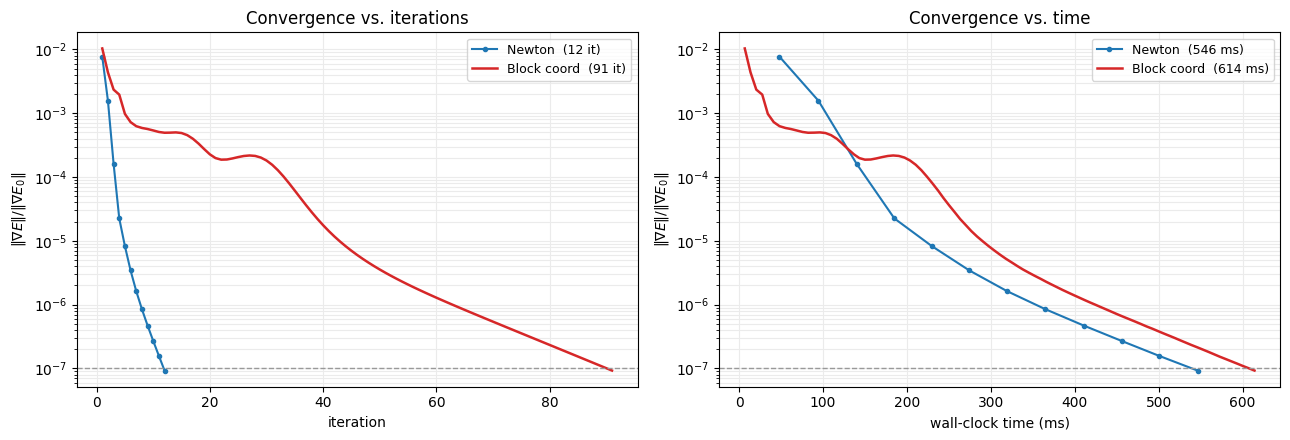

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].semilogy(np.arange(1, len(res_n)+1), res_n, "-o", ms=3, color="#1f77b4", label=f"Newton  ({len(res_n)} it)")
ax[0].semilogy(np.arange(1, len(res_b)+1), res_b, "-",  lw=1.8, color="#d62728", label=f"Block coord  ({len(res_b)} it)")
ax[1].semilogy(1e3*ts_n, res_n, "-o", ms=3, color="#1f77b4", label=f"Newton  ({1e3*ts_n[-1]:.0f} ms)")
ax[1].semilogy(1e3*ts_b, res_b, "-",  lw=1.8, color="#d62728", label=f"Block coord  ({1e3*ts_b[-1]:.0f} ms)")
for a, xl in zip(ax, ["iteration", "wall-clock time (ms)"]):
    a.axhline(RTOL, color="0.6", ls="--", lw=1); a.set_xlabel(xl)
    a.set_ylabel(r"$\|\nabla E\| / \|\nabla E_0\|$")
    a.grid(True, which="both", color="0.92"); a.legend(fontsize=9)
ax[0].set_title("Convergence vs. iterations"); ax[1].set_title("Convergence vs. time")
fig.tight_layout(); fig.savefig("media/21_convergence.png", dpi=130, bbox_inches="tight"); plt.show()

## The equilibrium shape

Both solvers reach the same ARAP minimizer (the rest beam is ghosted in gray).

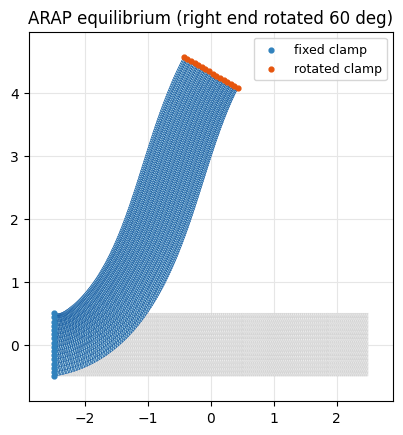

In [7]:
U = make_full(xn).reshape(n, dim)
lims = utils.auto_limits([X, U], pad=0.4)
fig, axx = plt.subplots(figsize=(7.5, 4.8))
utils.setup_axes(axx, *lims, title="ARAP equilibrium (right end rotated 60 deg)")
utils.PolyMeshArtist(axx, X, T, facecolor="#efefef", edgecolor="#cfcfcf", lw=0.3)   # rest ghost
utils.PolyMeshArtist(axx, U, T, facecolor="#9ecae1", edgecolor="#08519c", lw=0.3)
axx.scatter(X[left][:, 0], X[left][:, 1], s=12, color="#3182bd", zorder=5, label="fixed clamp")
axx.scatter(p_right[:, 0], p_right[:, 1], s=12, color="#e6550d", zorder=5, label="rotated clamp")
axx.legend(loc="upper right", fontsize=9); plt.show()

## Watching each solver converge

One frame per (sub-sampled) iteration. Block coordinate descent sweeps the beam
into the right gross shape almost immediately, then spends its long tail polishing;
Newton takes a few big curvature-aware steps.

In [8]:
def thin(states, target=50):
    k = max(1, len(states) // target); idx = list(range(0, len(states), k))
    if idx[-1] != len(states) - 1: idx.append(len(states) - 1)
    return [states[i] for i in idx]

clamp_pts = np.vstack([X[left], p_right])
lims = utils.auto_limits([X, make_full(xn).reshape(n, dim)], pad=0.4)
fig, anim = utils.animate_mesh(thin(states_b), T, lims=lims, fps=12,
    title="Block coordinate descent (local/global) converging", pin_pts=clamp_pts)
utils.show_video(fig, anim, "media/21_bcd.mp4", fps=12)

In [9]:
fig, anim = utils.animate_mesh(states_n, T, lims=lims, fps=5,
    title="Newton converging", pin_pts=clamp_pts)
utils.show_video(fig, anim, "media/21_newton.mp4", fps=5)

## Takeaways

* **Same minimizer, two cost structures.** Newton spends a lot per iteration
  (assemble a state-dependent Hessian, **re-factorize**, line-search) but converges
  in very few iterations thanks to curvature. Block coordinate descent factorizes
  **once** and every iteration is a parallel batch of polar decompositions plus a
  single back-substitution &mdash; cheap, but it needs many more of them because the
  constant rest-pose metric only models the curvature to first order.
* **Read the two plots together.** Iteration count and wall-clock time tell
  different stories; the right-hand panel is the one that matters in practice, and
  where it crosses depends on the mesh size, the accuracy you demand, and the cost
  of a factorization (which grows fast with problem size, especially in 3D).
* **The structure is the lesson.** `local_step` = per-element Procrustes
  (`polar_svd`); `global_step` = one prefactored Poisson solve. That "project, then
  solve a constant system" pattern is exactly projective dynamics, and it is what
  the next tutorial reuses for mass-springs.